In [1]:
import os
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show
from rasterio.plot import reshape_as_image
import matplotlib as mpl
import rasterio.mask
import numpy as np
import pandas as pd

# === UPDATED PATHS (adjusted folder name) ===
raw_base = r"F:\_____My_Thesies____\_ImpFiles"
data_dir = os.path.join(
    raw_base,
    "3. Feature Selection",
    "_Sentinel Data",
    "2. Divided Data",
    "2.Spectral"
)
# Ensure this matches the exact folder name on disk:
ref_shp = os.path.join(
    raw_base,
    "2.Segments",
    "_Final_Reference_Combined",
    "Ref_2024.shp"
)
year = 2024
spectral_tif = os.path.join(data_dir, f"{year}_Opt_SR.tif")

# --- 1) LOAD & INSPECT SHAPEFILE ---
print("Shapefile path:", ref_shp)
gdf = gpd.read_file(ref_shp)
print("Columns:", gdf.columns.tolist())
print("Number of polygons:", len(gdf))
print("Unique classes in 'layer':", gdf["layer"].unique())

# --- 2) LOAD & INSPECT SPECTRAL TIFF ---
print("\nSpectral TIFF path:", spectral_tif)
with rasterio.open(spectral_tif) as src:
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Number of bands:", src.count)
    print("Raster dimensions (height, width):", src.height, src.width)
    print("Resolution:", src.res)
    band1 = src.read(1)

Shapefile path: F:\_____My_Thesies____\_ImpFiles\2.Segments\_Final_Reference_Combined\Ref_2024.shp
Columns: ['fid_1', 'Name', 'descriptio', 'layer', 'path', 'Feature_ID', 'Area', 'geometry']
Number of polygons: 206
Unique classes in 'layer': ['Wheat-polygon' 'Rice-polygon' 'Clover-polygon' 'Alfalfa-polygon'
 'Corn-polygon' 'Sugar_Beet-polygon' 'Urban-polygon' 'Plowed-polygon'
 'Phragmites-polygon' 'Degreed_Wetland_Poly-polygon' 'Tamarix-polygon'
 'Mixed_TP-polygon' 'Bare-polygon']

Spectral TIFF path: F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\2.Spectral\2024_Opt_SR.tif
CRS: EPSG:4326
Bounds: BoundingBox(left=48.714470047932295, bottom=33.75653242052973, right=48.79280314070752, top=33.83576382858907)
Number of bands: 730
Raster dimensions (height, width): 882 872
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)


C:\Users\mamad_js\AppData\Local\Temp\ipykernel_15008\306451723.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("tab20", len(gdf["layer"].unique()))


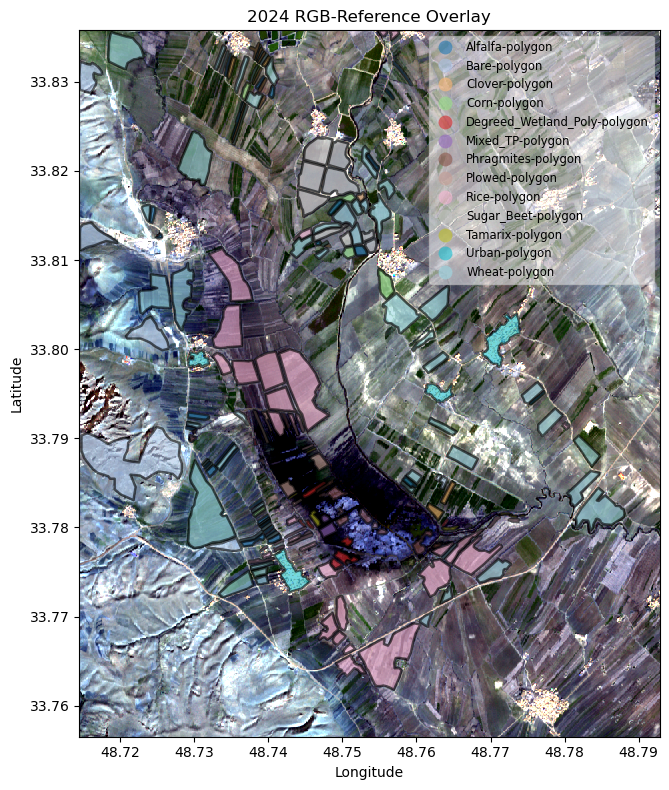

In [45]:
# 1) Load & reproject shapefile into raster CRS
gdf = gpd.read_file(ref_shp)
cmap = mpl.cm.get_cmap("tab20", len(gdf["layer"].unique()))

with rasterio.open(spectral_tif) as src:
    raster_crs = src.crs
    bounds     = src.bounds 
    rgb        = src.read([1,2,3])
    rgb_img    = reshape_as_image(rgb)

gdf = gdf.to_crs(raster_crs)

# 2) Stretch bands 2–98% (optional, makes it look nice)
rgb_stretched = np.zeros_like(rgb_img, dtype=np.float32)
for i in range(3):
    band = rgb_img[..., i].astype(np.float32)
    p2, p98 = np.percentile(band, (2,98))
    band = np.clip(band, p2, p98)
    rgb_stretched[..., i] = (band - p2)/(p98 - p2)

# 3) Plot with spatial extent
fig, ax = plt.subplots(figsize=(8,8))
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

ax.imshow(
    rgb_stretched,
    extent=extent,
    origin='upper',       
    interpolation='nearest'
)
ax.set_title("2024 RGB-Reference Overlay")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# 4) Overlay polygons
gdf.plot(
    ax=ax,
    column="layer",        
    cmap=cmap,               
    linewidth=1.8,            
    edgecolor="black",        
    alpha=0.6,               
    legend=True,            
    legend_kwds={
        "loc": "upper right",  
        "fontsize": "small",
        "framealpha": 0.5
    }
)

plt.tight_layout()
plt.show()

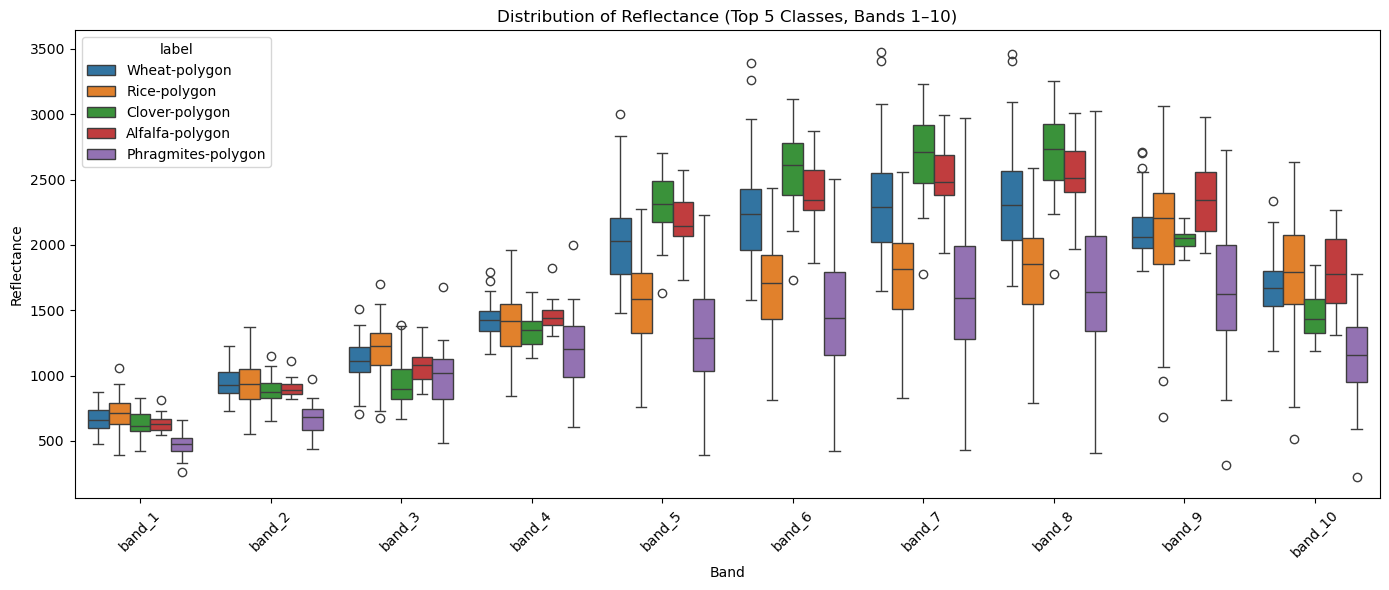

In [47]:
top_labels = df_melted['label'].value_counts().nlargest(5).index
subset_df = df_melted[
    df_melted['label'].isin(top_labels) &
    df_melted['Band'].isin([f'band_{i}' for i in range(1, 11)])
]

plt.figure(figsize=(14,6))
sns.boxplot(data=subset_df, x='Band', y='Reflectance', hue='label')
plt.title("Distribution of Reflectance (Top 5 Classes, Bands 1–10)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


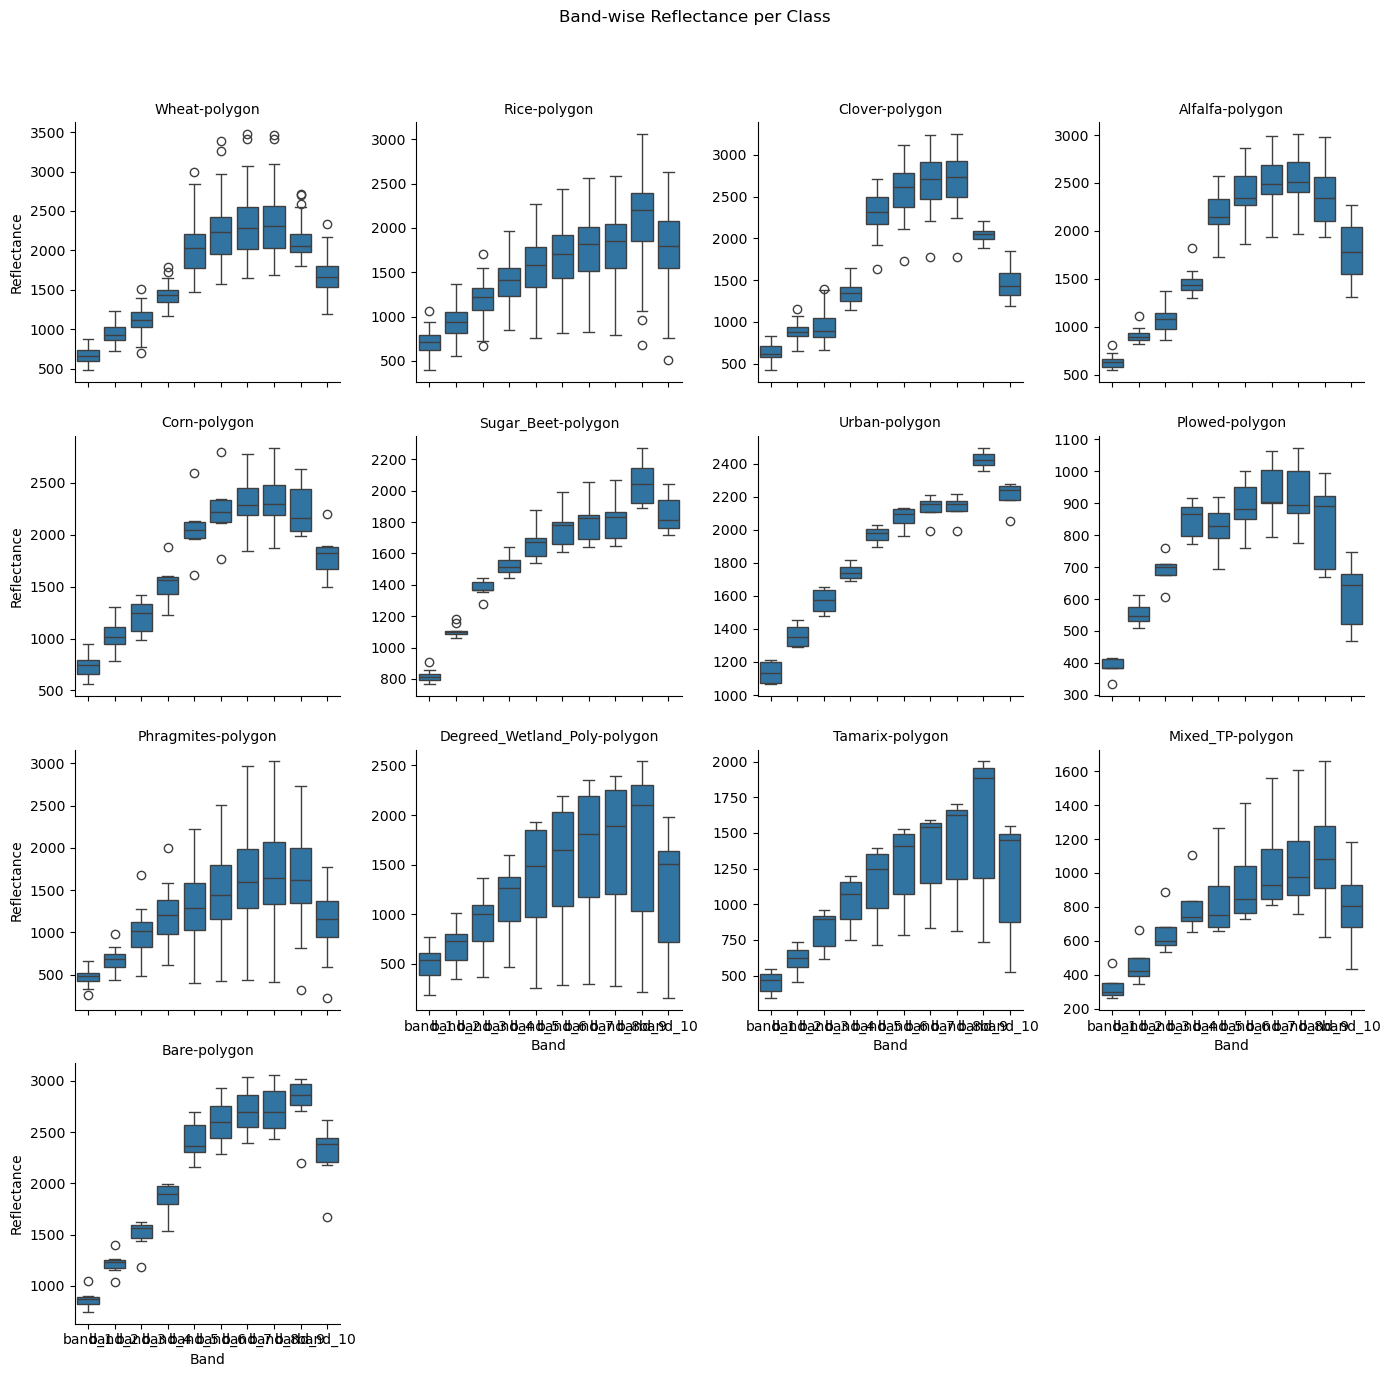

In [48]:
g = sns.FacetGrid(
    df_melted[df_melted['Band'].isin([f'band_{i}' for i in range(1,11)])],
    col="label", col_wrap=4, height=3.5, sharey=False
)
g.map_dataframe(sns.boxplot, x="Band", y="Reflectance", order=[f'band_{i}' for i in range(1,11)])
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Band-wise Reflectance per Class")
plt.show()


## Training data


In [1]:
import os
import geopandas as gpd
import rasterio
import pandas as pd
from tqdm import tqdm

# === 1) Set paths ===
raw_base = r"F:\_____My_Thesies____\_ImpFiles"
spectral_tif = os.path.join(raw_base, r"3. Feature Selection\_Sentinel Data\2. Divided Data\2.Spectral\2024_Opt_SR.tif")
ref_shp     = os.path.join(raw_base, r"2.Segments\_Final_Reference_Combined\Ref_2024.shp")

# === 2) Load shapefile and get centroids ===
gdf = gpd.read_file(ref_shp).to_crs("EPSG:4326")  # match raster CRS
gdf["centroid"] = gdf.geometry.centroid
gdf["coords"] = gdf["centroid"].apply(lambda p: (p.x, p.y))

# === 3) Open raster and sample values at centroids ===
with rasterio.open(spectral_tif) as src:
    band_count = src.count
    band_names = [f'band_{i}' for i in range(1, band_count+1)]
    values = list(src.sample(gdf["coords"]))  

    
# === 4) Combine data ===
df = pd.DataFrame(values, columns=band_names)
df["label"] = gdf["layer"].values  # adjust if column name is different
df["ID"] = gdf["Name"].values if "Name" in gdf.columns else gdf.index

# === 5) Export for ML use ===
df.to_csv("OBIA_Centroid_Spectral_Values.csv", index=False)
print("✅ Saved: OBIA_Centroid_Spectral_Values.csv")


C:\Users\mamad_js\AppData\Local\Temp\ipykernel_2676\611284745.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid"] = gdf.geometry.centroid


✅ Saved: OBIA_Centroid_Spectral_Values.csv


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# === 1) Load the data ===
df = pd.read_csv("OBIA_Centroid_Spectral_Values.csv")
# === 2) Drop non-numeric or metadata columns ===
X = df.select_dtypes(include='number')  # Keeps only numeric columns
y = df['label']

# === 3) Train-Test Split (70-30) ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# === 4) Train Random Forest ===
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
clf.fit(X_train, y_train)

# === 5) Evaluate ===
y_pred = clf.predict(X_test)
print("📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# === 6) Optional: 5-fold Cross-validation ===
cv_scores = cross_val_score(clf, X, y, cv=StratifiedKFold(5), scoring='f1_weighted')
print(f"✅ Mean F1-score (CV): {cv_scores.mean():.4f}")

📊 Classification Report:
                               precision    recall  f1-score   support

             Alfalfa-polygon       0.88      0.88      0.88         8
                Bare-polygon       1.00      0.50      0.67         2
              Clover-polygon       0.75      0.75      0.75         4
                Corn-polygon       1.00      1.00      1.00         2
Degreed_Wetland_Poly-polygon       0.33      0.50      0.40         2
            Mixed_TP-polygon       1.00      1.00      1.00         1
          Phragmites-polygon       1.00      0.40      0.57         5
              Plowed-polygon       0.50      1.00      0.67         2
                Rice-polygon       0.92      1.00      0.96        12
          Sugar_Beet-polygon       1.00      0.67      0.80         3
             Tamarix-polygon       1.00      0.50      0.67         2
               Urban-polygon       1.00      1.00      1.00         1
               Wheat-polygon       0.90      1.00      0.95    

c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


✅ Mean F1-score (CV): 0.8234


In [7]:
import pandas as pd
import os

# === 1. Load Your CSV ===
df = pd.read_csv("OBIA_Centroid_Spectral_Values.csv")

# === 2. Load Band Names File ===
band_names_file = r"F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\_Bands_Names\2024_SR Bands Names.txt"
with open(band_names_file, 'r') as f:
    all_band_names = [line.strip() for line in f.readlines()]

# === 3. Filter to only optical bands (those starting with 'B') ===
optical_band_names = [name for name in all_band_names if name.startswith('B')]

# === 4. Check number of bands match ===
band_cols = [col for col in df.columns if col.startswith('band_')]
if len(band_cols) != len(optical_band_names):
    raise ValueError(f"Mismatch: {len(band_cols)} band columns in CSV, but {len(optical_band_names)} optical band names in the .txt file.")

# === 5. Rename the band columns in the DataFrame ===
rename_dict = dict(zip(band_cols, optical_band_names))
df = df.rename(columns=rename_dict)

# === 6. Save updated CSV ===
df.to_csv("OBIA_Spectral_Samples_Labeled.csv", index=False)
print("✅ Updated CSV saved as 'OBIA_Spectral_Samples_Labeled.csv'")


✅ Updated CSV saved as 'OBIA_Spectral_Samples_Labeled.csv'


C:\Users\mamad_js\AppData\Local\Temp\ipykernel_2676\762579993.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], ax=ax2, palette="viridis")


(<Figure size 800x600 with 2 Axes>,
 <Figure size 1000x600 with 1 Axes>,
 <Figure size 1000x700 with 1 Axes>,
 <Figure size 1000x700 with 1 Axes>)

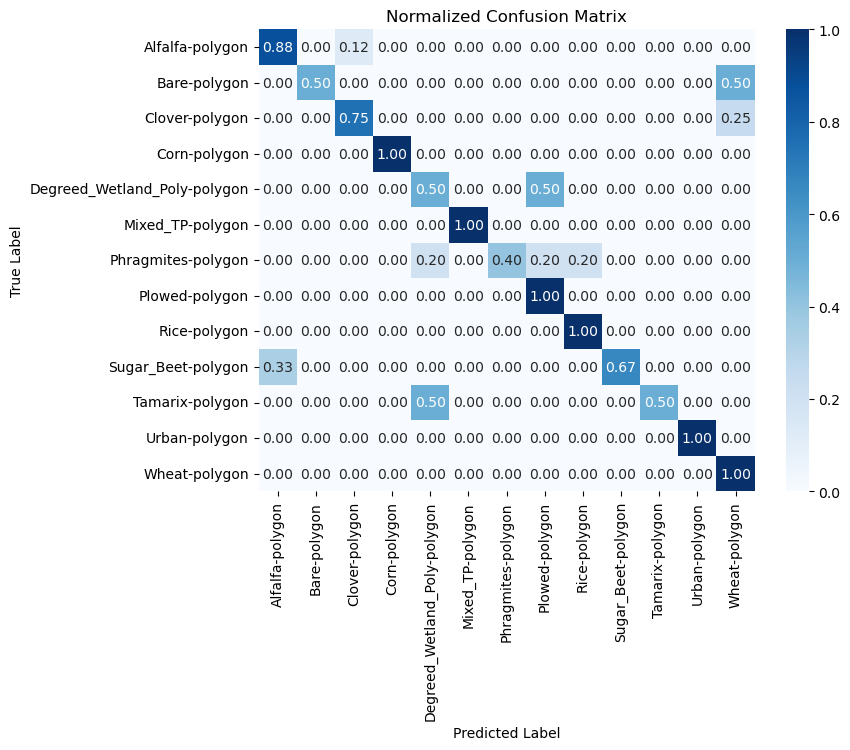

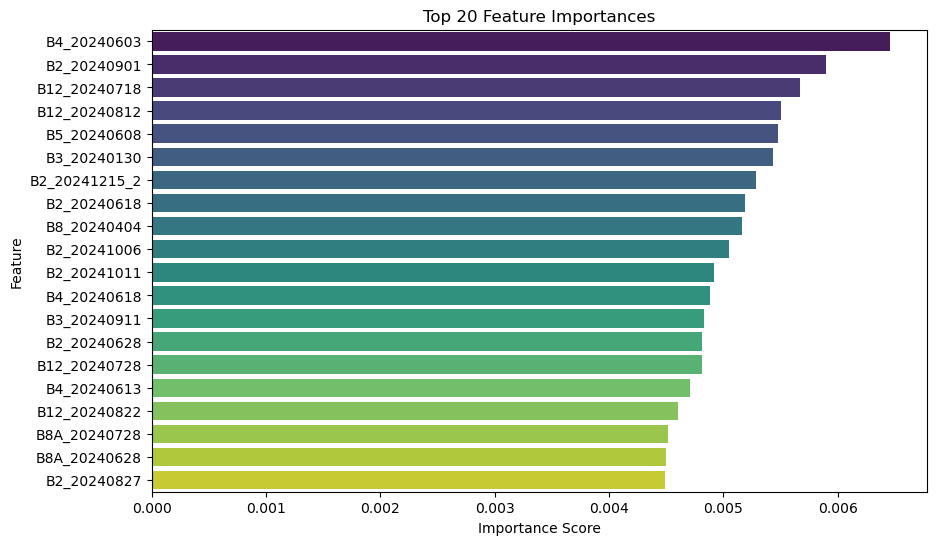

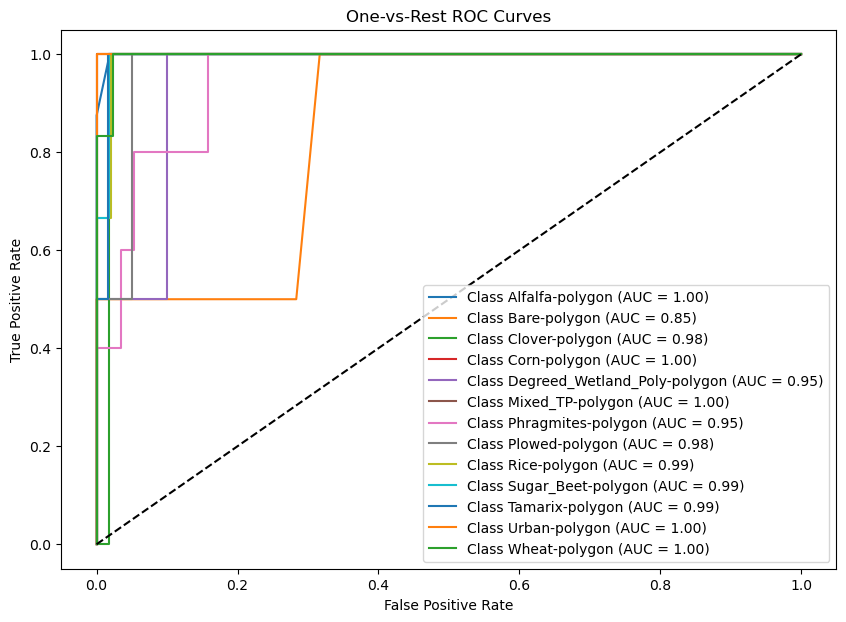

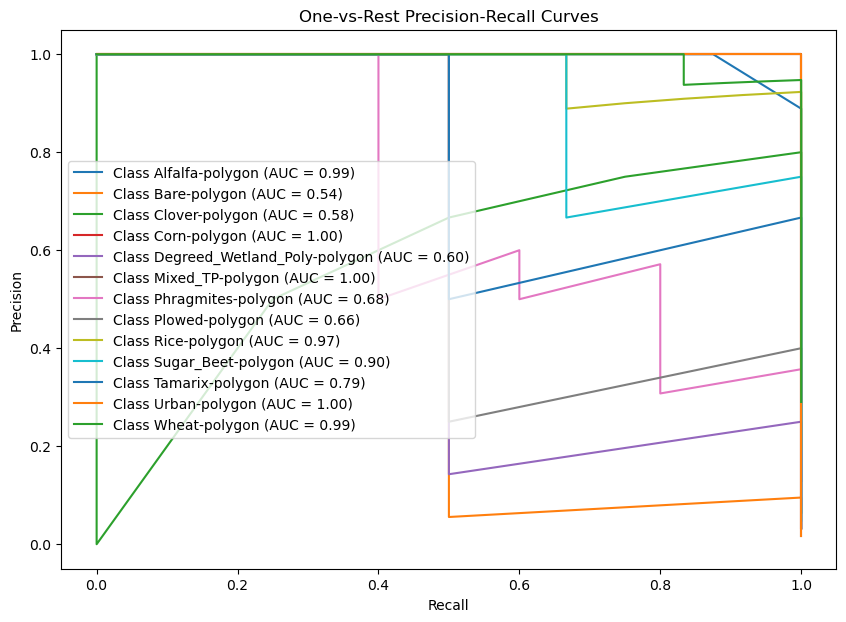

In [8]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode the labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Extract features and labels
X = df.select_dtypes(include='number').drop(columns=['label_encoded'], errors='ignore')
y = df['label_encoded']
labels = le.classes_

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Train the Random Forest model
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
clf.fit(X_train, y_train)

# Predict labels and probabilities
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

# Confusion Matrix
fig1, ax1 = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax1)
ax1.set_title('Normalized Confusion Matrix')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# Feature Importance
importances = clf.feature_importances_
indices = importances.argsort()[::-1][:20]
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], ax=ax2, palette="viridis")
ax2.set_title('Top 20 Feature Importances')
ax2.set_xlabel('Importance Score')
ax2.set_ylabel('Feature')

# ROC Curves
fig3, ax3 = plt.subplots(figsize=(10, 7))
for i in range(len(labels)):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
    ax3.plot(fpr, tpr, label=f'Class {labels[i]} (AUC = {auc(fpr, tpr):.2f})')
ax3.plot([0, 1], [0, 1], 'k--')
ax3.set_title('One-vs-Rest ROC Curves')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend()

# Precision-Recall Curves
fig4, ax4 = plt.subplots(figsize=(10, 7))
for i in range(len(labels)):
    precision, recall, _ = precision_recall_curve((y_test == i).astype(int), y_prob[:, i])
    ax4.plot(recall, precision, label=f'Class {labels[i]} (AUC = {auc(recall, precision):.2f})')
ax4.set_title('One-vs-Rest Precision-Recall Curves')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.legend()

(fig1, fig2, fig3, fig4)

## Predict

In [ ]:
df

In [15]:
import rasterio
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier

# === Your trained classifier ===
# If you saved it before:
# import joblib
# clf = joblib.load('rf_model.joblib')

# Or if clf is still in memory, use directly

# === Load band names from your dataframe columns ===
real_band_names = [col for col in df.columns if col.startswith('B')]

# Robust parsing function for band and date (handles suffixes)
def parse_band_date(name):
    parts = name.split('_')
    date_str = None
    band_parts = []
    for part in parts:
        if len(part) == 8 and part.isdigit():
            date_str = part
        else:
            band_parts.append(part)
    if date_str is None:
        raise ValueError(f"No valid date found in band name: {name}")
    band = '_'.join(band_parts)
    date = datetime.strptime(date_str, "%Y%m%d")
    return band, date

# Build DataFrame with band info
band_info = pd.DataFrame(
    [parse_band_date(bn) for bn in real_band_names],
    columns=['band', 'date'], index=real_band_names
)

# === Load the raster ===
tif_path = r"F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\2.Spectral\2024_Opt_SR.tif"
with rasterio.open(tif_path) as src:
    profile = src.profile
    height, width = src.height, src.width
    img = src.read()  # shape: (bands, rows, cols)
    img = np.moveaxis(img, 0, -1)  # (rows, cols, bands)

# Flatten raster to 2D pixels x bands
img_2d = img.reshape(-1, img.shape[2])

# === Hierarchical temporal imputation ===
img_filled = img_2d.copy()

for idx, band_name in enumerate(real_band_names):
    band_vals = img_2d[:, idx]
    nan_mask = np.isnan(band_vals)
    if not nan_mask.any():
        continue
    
    band, date = parse_band_date(band_name)
    
    # Step 1: Mean of this band-date across all pixels
    mean_same_date = np.nanmean(band_vals)
    
    # Step 2: Mean of same band ±31 days window (3 months approx)
    window = pd.Timedelta(days=31)
    nearby_bands = band_info[
        (band_info['band'] == band) &
        (abs(band_info['date'] - date) <= window)
    ].index.tolist()
    
    if len(nearby_bands) > 1:
        nearby_vals = img_2d[:, [real_band_names.index(b) for b in nearby_bands]]
        mean_nearby = np.nanmean(nearby_vals, axis=1)
    else:
        mean_nearby = np.full(band_vals.shape, np.nan)
    
    # Step 3: Mean of the band across all time (all dates)
    all_dates_bands = band_info[band_info['band'] == band].index.tolist()
    all_dates_vals = img_2d[:, [real_band_names.index(b) for b in all_dates_bands]]
    mean_all_time = np.nanmean(all_dates_vals, axis=1)
    
    # Fill NaNs hierarchically
    filled_vals = band_vals.copy()
    # Fill with mean same date if NaN
    filled_vals[nan_mask] = mean_same_date
    # Replace NaNs with mean nearby if mean_same_date was NaN or fill didn't fix
    still_nan = np.isnan(filled_vals)
    filled_vals[still_nan] = mean_nearby[still_nan]
    # Replace NaNs with mean all time if still NaN
    still_nan = np.isnan(filled_vals)
    filled_vals[still_nan] = mean_all_time[still_nan]
    
    # Update the filled array
    img_filled[:, idx] = filled_vals

# === Predict on imputed data ===
pred_full = clf.predict(img_filled)
pred_raster = pred_full.reshape((height, width))

# === Save prediction raster ===
output_path = tif_path.replace(".tif", "_Classified.tif")
profile.update(count=1, dtype=rasterio.int32)

with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(pred_raster.astype(rasterio.int32), 1)

print(f"✅ Prediction saved: {output_path}")


C:\Users\mamad_js\AppData\Local\Temp\ipykernel_2676\4220691532.py:62: RuntimeWarning: Mean of empty slice
  mean_same_date = np.nanmean(band_vals)
c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Prediction saved: F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\2.Spectral\2024_Opt_SR_Classified.tif


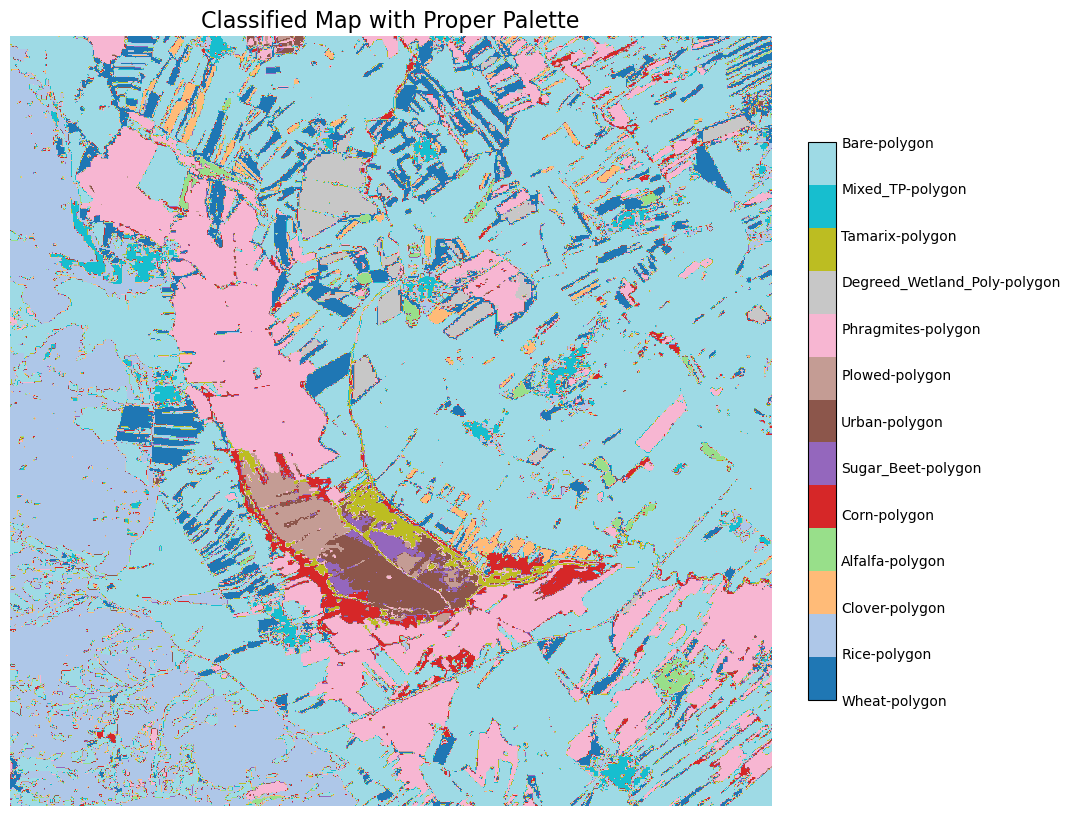

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import numpy as np

# Your classes and colors
classes = [
    'Wheat-polygon', 'Rice-polygon', 'Clover-polygon', 'Alfalfa-polygon',
    'Corn-polygon', 'Sugar_Beet-polygon', 'Urban-polygon', 'Plowed-polygon',
    'Phragmites-polygon', 'Degreed_Wetland_Poly-polygon', 'Tamarix-polygon',
    'Mixed_TP-polygon', 'Bare-polygon'
]

# Create a categorical color map with enough distinct colors (use tab20 or create custom)
cmap = plt.get_cmap('tab20', len(classes))  # tab20 has 20 distinct colors

# Build mapping from class label to integer (if not already done)
class_to_int = {c: i for i, c in enumerate(classes)}

# If your prediction is numeric labels (ints from 0 to n_classes-1), then great
# Otherwise, map prediction labels to class ints accordingly

# Load your predicted raster array here (already done in your previous step)
# pred_raster shape: (height, width), values = predicted class indices

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

# Show classified map
im = ax.imshow(pred_raster, cmap=cmap, vmin=0, vmax=len(classes)-1)

# Create a colorbar with class names
cbar = plt.colorbar(im, ticks=range(len(classes)), fraction=0.03, pad=0.04)
cbar.ax.set_yticklabels(classes, fontsize=10)
cbar.ax.tick_params(length=0)

ax.set_title('Classified Map with Proper Palette', fontsize=16)
ax.axis('off')

plt.show()


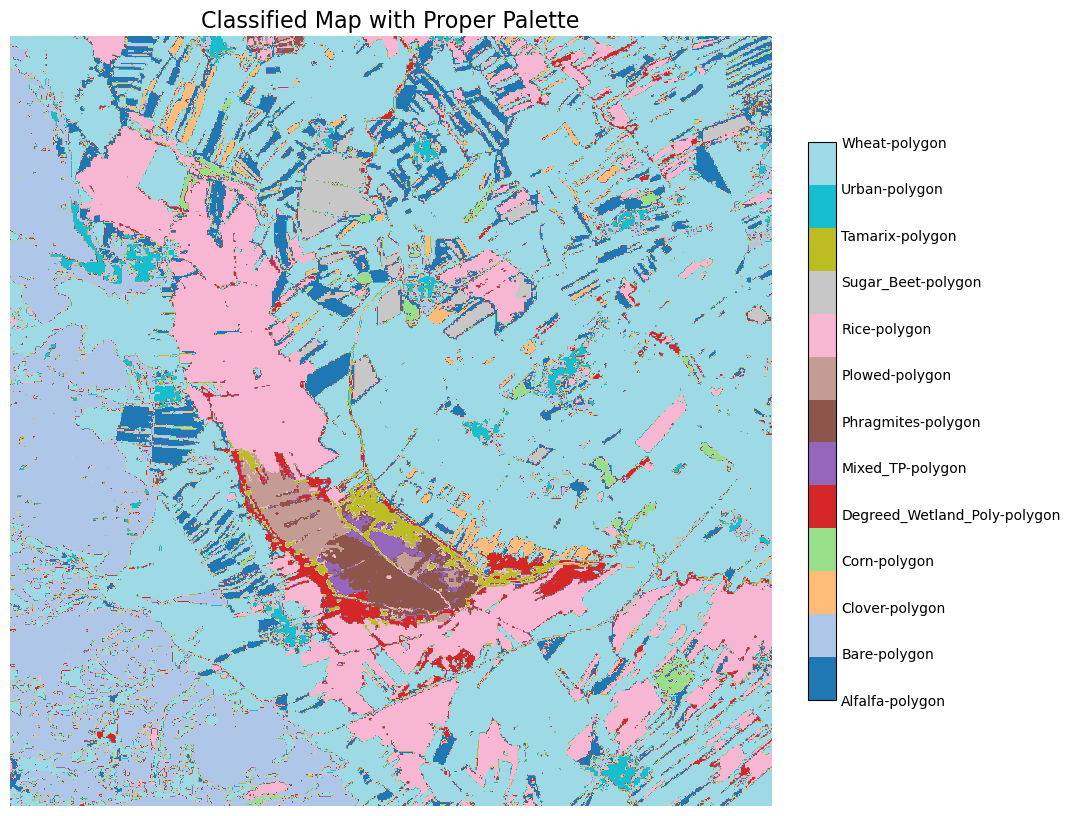

In [18]:
# classes from your label encoder
classes = le.classes_  

# Build colormap
cmap = plt.get_cmap('tab20', len(classes))

# Plot prediction raster (integers from 0 to n_classes-1)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(pred_raster, cmap=cmap, vmin=0, vmax=len(classes)-1)
ax.axis('off')
ax.set_title('Classified Map with Proper Palette', fontsize=16)

# Colorbar with proper class names
cbar = plt.colorbar(im, ticks=range(len(classes)), fraction=0.03, pad=0.04)
cbar.ax.set_yticklabels(classes, fontsize=10)
cbar.ax.tick_params(length=0)

plt.show()
